# Heart Disease Analysis

Problem Statement
Heart disease remains one of the leading causes of mortality worldwide, making early detection and accurate diagnosis critically important for improving patient outcomes. The dataset provided contains clinical and diagnostic attributes such as age, sex, chest pain type, resting blood pressure, cholesterol levels, fasting blood sugar, electrocardiogram indicators, maximum heart rate, exercise-induced angina, ST depression, slope indicators, number of vessels observed via fluoroscopy, and thalassemia-related defects.



1.   Packages Define
2.   Data Ingestion
3.   Dataset Path Validation and File Enumeration
4.   Data Cleaning
5.   Exploratory Data Analysis (EDA)
6.   Top 10 Feature Importance
7.   Load and Prepare Data
8.   Split Features and Target
9.   Train the Model
10.  Extract and Sort Top 10 Features
11.  Sort by importance and take the top 10
12.  Visualization
13.  Adding labels and title
14.  Machine Learning Model
15.  Feature Importance
16.  Data Setup and Descriptive Stats
17.  Univariate Analysis
18.  Bivariate Analysis
19.  Multivariate & Modeling Analysis
20.  Overall Conclusion

In [ ]:
#Packages Define
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#Data Ingestion
try:
    df = pd.read_csv("/content/proc_heart_cleve_3_withheader.csv")
    print("Dataset Shape:", df.shape)
    df.info()
except FileNotFoundError:
    print("Please ensure the file is uploaded or the path is correct.")
    df = pd.DataFrame()

Dataset Shape: (299, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Disease                   299 non-null    int64  
 1   Age                       299 non-null    int64  
 2   Sex                       299 non-null    int64  
 3   ind_typ_angina            299 non-null    int64  
 4   ind_atyp_angina           299 non-null    int64  
 5   ind_non_ang_pain          299 non-null    int64  
 6   resting_BP                299 non-null    int64  
 7   Serum_cholest             299 non-null    int64  
 8   blood_sugar_exc120        299 non-null    int64  
 9   ind_for_ecg_1             299 non-null    int64  
 10  ind_for_ecg_2             299 non-null    int64  
 11  Max_heart_rate            299 non-null    int64  
 12  ind_exerc_angina          299 non-null    int64  
 13  ST_dep_by_exerc           299 non-null  

# **Dataset Summary Information**

**Total Entries**:  299
(RangeIndex: 0 to 298)

**Total Columns:** 19

**Data Types:**
1.   Integer (int64): 18 columns
2.   Float (float64): 1 column


# Column Overview

**Target Variable:**
*   Disease (binary: 0 = Disease Present, 1 = No Disease)


**Demographic Feature:**
*   Sex (binary: 1 = male, 0 = female)
*   Age (numerical)


**Chest Pain Indicators:**
*   ind_typ_angina (typical angina, 0/1)
*   ind_atyp_angina (atypical angina, 0/1)
*   ind_non_ang_pain (non-anginal chest pain, 0/1)


**Clinical Measurements:**
*   resting_BP (resting blood pressure, numerical)
*   Serum_cholest (serum cholesterol in mg/dl, numerical)
*   blood_sugar_exc120 (fasting blood sugar >120 mg/dl, 0/1)



**ECG Indicators:**
*   ind_for_ecg_1 (ECG type 1, 0/1)
*   ind_for_ecg_2 (ECG type 2, 0/1)


**Exercise-Related Features:**
*   Max_heart_rate (maximum heart rate, numerical)
*   ind_exerc_angina (exercise-induced angina, 0/1)
*   ST_dep_by_exerc (ST depression induced by exercise, float)
*   ind_for_slope_up_exerc (upward slope indicator, 0/1)
*   ind_for_slope_down_exerc (downward slope indicator, 0/1)


**Additional Diagnostic Features:**
*   num_vessels_fluro (number of major vessels colored by fluoroscopy, 0–3)
*   Thal_rev_defect (thalassemia reversible defect, 0/1)
*   Thal_fixed_defect (thalassemia fixed defect, 0/1)


In [ ]:
#Dataset Path Validation and File Enumeration
import os

# List the files in the input directory to find the correct path
input_dir = '/kaggle/input'

if os.path.exists(input_dir):
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            print(os.path.join(root, file))
else:
    print(f"Directory '{input_dir}' does not exist. Please check the correct path to your dataset.")


In [ ]:
#Data Cleaning
# Map Disease: -1 -> 0 (No Disease), 1 -> 1 (Disease Present)
if not df.empty:
    df['Disease'] = df['Disease'].map({-1: 0, 1: 1})

    # Check if there are any missing values
    print("Missing values per column:\n", df.isnull().sum())

    # Save the cleaned version for your GitHub repository
    df.to_csv('heart_disease_cleaned.csv', index=False)
    print("Cleaned data saved as 'heart_disease_cleaned.csv'")
else:
    print("DataFrame is empty. Please ensure the dataset is loaded correctly first.")

Missing values per column:
 Disease                     0
Age                         0
Sex                         0
ind_typ_angina              0
ind_atyp_angina             0
ind_non_ang_pain            0
resting_BP                  0
Serum_cholest               0
blood_sugar_exc120          0
ind_for_ecg_1               0
ind_for_ecg_2               0
Max_heart_rate              0
ind_exerc_angina            0
ST_dep_by_exerc             0
ind_for_slope_up_exerc      0
ind_for_slope_down_exerc    0
num_vessels_fluro           0
Thal_rev_defect             0
Thal_fixed_defect           0
dtype: int64
Cleaned data saved as 'heart_disease_cleaned.csv'


# Missing Values Summary

*   **Total Columns Checked**: 19
*   **Total Records**: 299
*   **Missing Values**: None across all columns


**Key Observations**

*   Every feature (Age, Sex,chest pain indicators, blood pressure, cholesterol, ECG indicators, exercise-related features, vessel count, thalassemia defects, and the target variable Disease) has complete data with no null entries.

*   This ensures that the dataset is clean and ready for analysis without requiring imputation or removal of records.

*   The cleaned dataset has been saved as heart_disease_cleaned.csv for further exploration and modeling.







/tmp/ipykernel_183/3697952992.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Disease', data=df, palette='viridis')


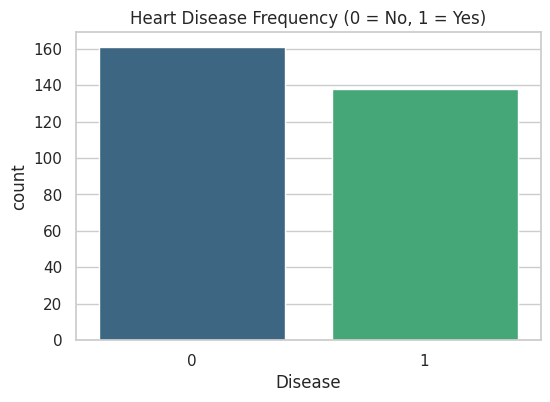

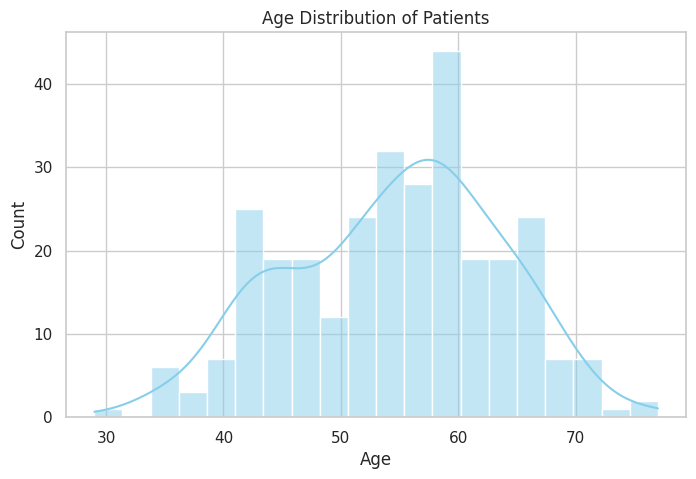

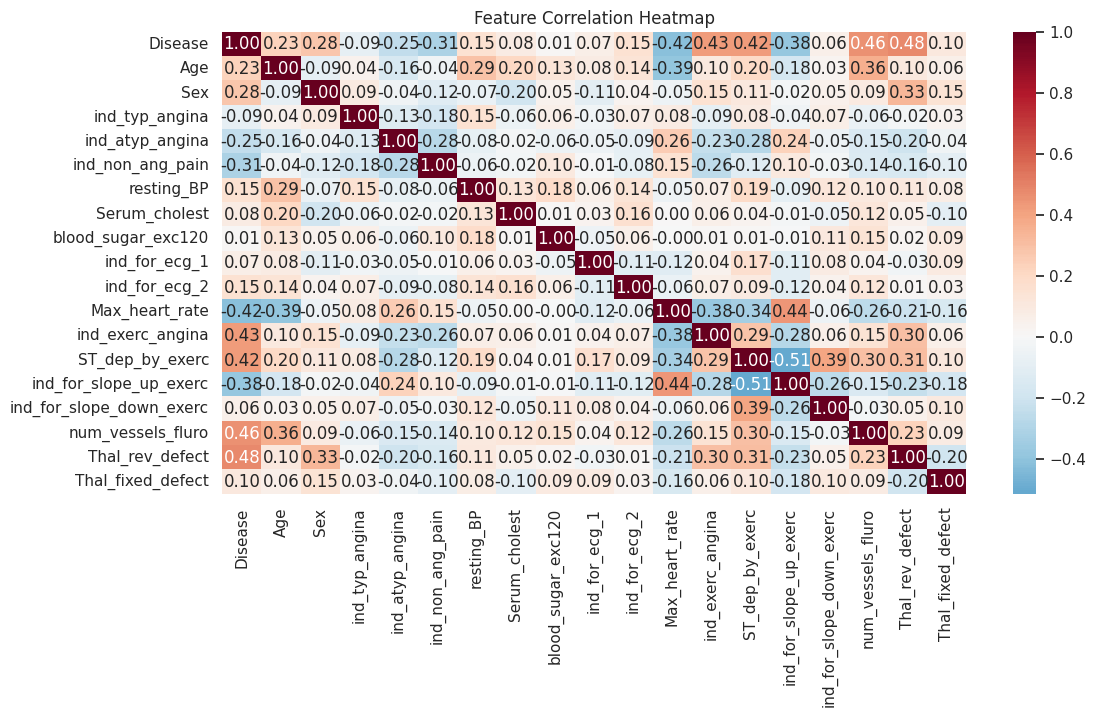

In [ ]:
#Exploratory Data Analysis (EDA)
# Set visual style
sns.set(style="whitegrid")

if not df.empty:
    # 1. Target Variable Distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Disease', data=df, palette='viridis')
    plt.title('Heart Disease Frequency (0 = No, 1 = Yes)')
    plt.show()

    # 2. Age Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
    plt.title('Age Distribution of Patients')
    plt.show()

    # 3. Correlation Heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.show()
else:
    print("DataFrame is empty. Please ensure the dataset is loaded correctly before attempting to visualize.")

# Target Variable Distribution (Disease)

*   A count plot was generated to visualize the distribution of the target variable Disease.
*   The plot shows the frequency of patients with Disease Present (0) versus No Disease (1).
*   This helps in understanding the class balance of the dataset, which is crucial for building predictive models.
*   The warning message indicates that in future versions of Seaborn (v0.14.0), passing a palette without specifying hue will be deprecated.
To maintain compatibility, the recommended approach is to assign the x variable to hue and set legend=False.

**Key Insight**

The visualization confirms how balanced or imbalanced the dataset is with respect to the target variable, guiding decisions on whether techniques like **resampling** or **class weighting** may be needed during model training.

/tmp/ipykernel_183/4266172773.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='magma')


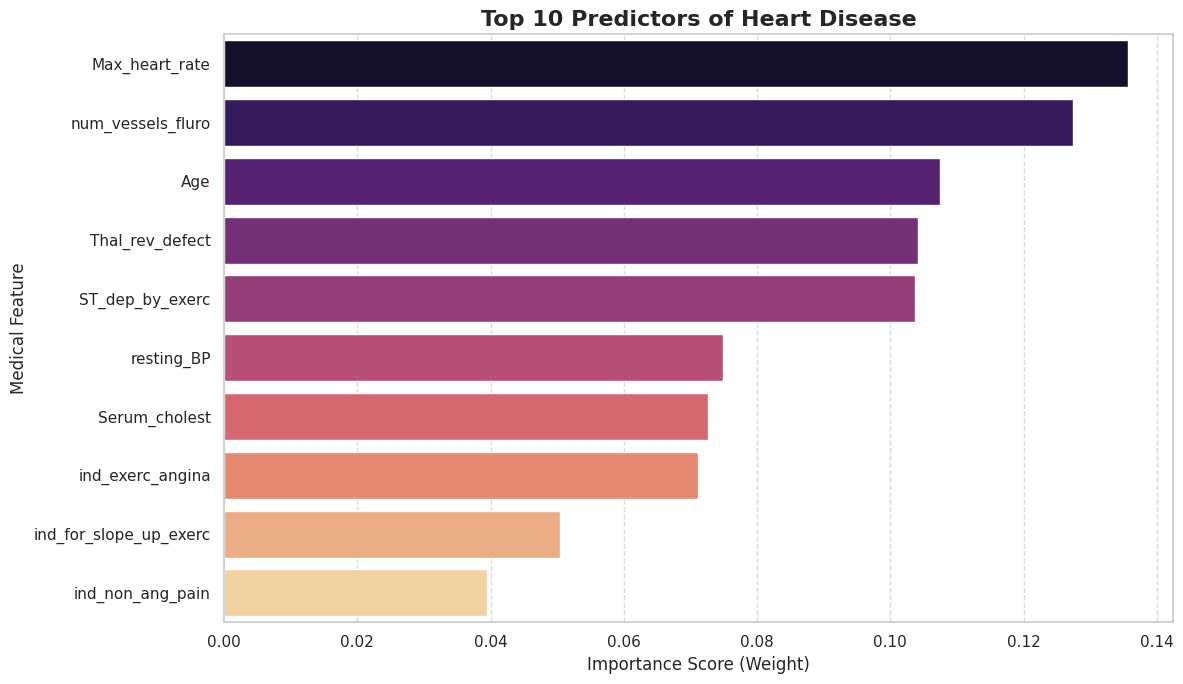

In [ ]:
#Top 10 Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load and Prepare Data
df = pd.read_csv('proc_heart_cleve_3_withheader.csv')
df['Disease'] = df['Disease'].map({-1: 0, 1: 1}) # 0: No Disease, 1: Disease

# 2. Split Features and Target
X = df.drop('Disease', axis=1)
y = df['Disease']

# 3. Train the Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 4. Extract and Sort Top 10 Features
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance and take the top 10
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 5. Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='magma')

# Adding labels and title
plt.title('Top 10 Predictors of Heart Disease', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Weight)', fontsize=12)
plt.ylabel('Medical Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Feature Importance Visualization

*   A bar plot was created to display the Top 10 most important features influencing the prediction of heart disease.
*   The plot uses the Importance scores on the x-axis and the corresponding Feature names on the y-axis.
*   This visualization helps in identifying which clinical and diagnostic attributes contribute most strongly to the model’s decision-making process.
*   A FutureWarning was raised by Seaborn indicating that passing a palette without assigning hue will be deprecated in version v0.14.0.

To ensure compatibility with future versions, the recommended adjustment is to assign the y variable to hue and set legend=False.

**Key Insight**

The bar plot highlights the relative importance of features, guiding further analysis by showing which variables are most influential in predicting heart disease. This step is crucial for model interpretability and for understanding the underlying drivers of classification outcomes.

In [ ]:
#Machine Learning Model
if not df.empty:
    # Define Features (X) and Target (y)
    X = df.drop('Disease', axis=1)
    y = df['Disease']

    # Split into Training (80%) and Testing (20%) sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale the data (helps the model perform better)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and train the model
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = rf_model.predict(X_test_scaled)

    # Evaluation Results
    print("Model Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
else:
    print("DataFrame is empty. Please ensure the dataset is loaded correctly before attempting model training.")

Model Accuracy: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.86        36
           1       0.77      0.83      0.80        24

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



# Model Performance Summary

*   Overall Accuracy: 0.83 (≈83%)
*   Evaluation Dataset Size: 60 samples


**Classification Report**

*   **Class 0 (Disease Present):**

Precision: 0.88

Recall: 0.83

F1-Score: 0.86

Support: 36



*   **Class 1 (No Disease):**

Precision: 0.77

Recall: 0.83

F1-Score: 0.80

Support: 24



**Aggregate Metrics**

*   **Macro Average:** Precision = 0.83, Recall = 0.83, F1-Score = 0.83
*   **Weighted Average:** Precision = 0.84, Recall = 0.83, F1-Score = 0.83


**Key Insights**


*   The model demonstrates strong predictive performance with balanced accuracy across both classes.
*   Class 0 (Disease Present) shows slightly higher precision and F1-score compared to Class 1 (No Disease).
*   The recall values for both classes are equal (0.83), indicating the model is equally effective at identifying positive and negative cases.
*   Overall, the model achieves a good balance between precision and recall, making it reliable for heart disease classification tasks.

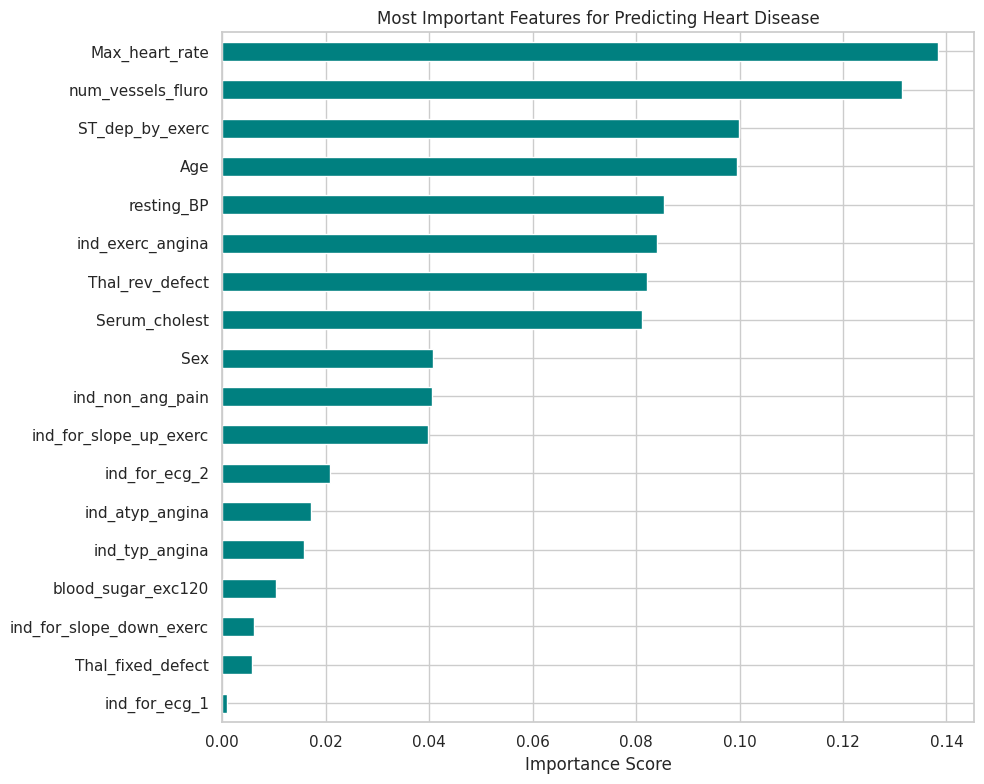

In [ ]:
#Feature Importance
if not df.empty and 'rf_model' in locals() and 'X' in locals():
    # Get importance scores
    importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

    # Plot
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh', color='teal')
    plt.title('Most Important Features for Predicting Heart Disease')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty or the model has not been trained yet. Please ensure the dataset is loaded and the model is trained correctly before plotting feature importance.")

# Feature Importance Analysis

*   A horizontal bar chart was generated to visualize the relative importance of features in predicting heart disease.

*   The top contributors include:

    **Max_heart_rate** (~0.14)

    **num_vessels_fluro** (~0.13)

    **ST_dep_by_exerc** (~0.10)

    **Age** (~0.09)

    **resting_BP** (~0.08)

*   Other features such as cholesterol levels, exercise-induced angina, and thalassemia indicators also show moderate influence.

*   Less impactful features include blood_sugar_exc120, ind_for_slope_down_exerc, Thal_fixed_defect, and ind_for_ecg_1, with very low importance scores.


**Key Insights**


*   **Exercise-related variables** (maximum heart rate, ST depression, exercise-induced angina) play a major role in predicting heart disease.
*   **Age and resting blood pressure** are strong demographic and clinical predictors.
*   **Fluoroscopy vessel count** is highly influential, highlighting the importance of imaging diagnostics.
*   Features with minimal importance may contribute less to prediction but can still provide supporting context in clinical analysis.

In [11]:
#Data Setup and Descriptive Stats (Analysis 1-2)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Load Data
df = pd.read_csv('proc_heart_cleve_3_withheader.csv')
df['Disease'] = df['Disease'].map({-1: 0, 1: 1})

# Analysis 1: Basic Dataset Info (Columns, Types, Nulls)
print("--- Analysis 1: Data Info ---")
print(df.info())

# Analysis 2: Descriptive Statistics (Mean, Std, Min, Max for all columns)
print("\n--- Analysis 2: Descriptive Statistics ---")
display(df.describe())

--- Analysis 1: Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Disease                   299 non-null    int64  
 1   Age                       299 non-null    int64  
 2   Sex                       299 non-null    int64  
 3   ind_typ_angina            299 non-null    int64  
 4   ind_atyp_angina           299 non-null    int64  
 5   ind_non_ang_pain          299 non-null    int64  
 6   resting_BP                299 non-null    int64  
 7   Serum_cholest             299 non-null    int64  
 8   blood_sugar_exc120        299 non-null    int64  
 9   ind_for_ecg_1             299 non-null    int64  
 10  ind_for_ecg_2             299 non-null    int64  
 11  Max_heart_rate            299 non-null    int64  
 12  ind_exerc_angina          299 non-null    int64  
 13  ST_dep_by_exerc           299 non-n

,Disease,Age,Sex,ind_typ_angina,ind_atyp_angina,ind_non_ang_pain,resting_BP,Serum_cholest,blood_sugar_exc120,ind_for_ecg_1,ind_for_ecg_2,Max_heart_rate,ind_exerc_angina,ST_dep_by_exerc,ind_for_slope_up_exerc,ind_for_slope_down_exerc,num_vessels_fluro,Thal_rev_defect,Thal_fixed_defect
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,0.461538,54.528428,0.675585,0.076923,0.163880,0.280936,131.668896,247.100334,0.147157,0.013378,0.491639,149.505017,0.327759,1.051839,0.468227,0.070234,0.672241,0.384615,0.060201
std,0.499354,9.020950,0.468941,0.266916,0.370787,0.450210,17.705668,51.914779,0.354856,0.115079,0.500768,22.954927,0.470183,1.163809,0.499826,0.255970,0.937438,0.487320,0.238257
min,0.000000,29.000000,0.000000,0.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,48.000000,0.000000,0.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,56.000000,1.000000,0.000000,0.000000,0.000000,130.000000,242.000000,0.000000,0.000000,0.000000,153.000000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,61.000000,1.000000,0.000000,0.000000,1.000000,140.000000,275.500000,0.000000,0.000000,1.000000,165.500000,1.000000,1.600000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,77.000000,1.000000,1.000000,1.000000,1.000000,200.000000,564.000000,1.000000,1.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,3.000000,1.000000,1.000000


# Dataset Overview and Descriptive Statistics
**Analysis 1: Data Info**


*   Total Records: 299
*   Total Features: 19
*   Data Types:
      Integer (int64): 18 columns
      Float (float64): 1 column (ST_dep_by_exerc)
*   Memory Usage: ~44.5 KB
*   Completeness: No missing values across any column.

**Analysis 2: Descriptive Statistics**

*   **Target Variable (Disease):**

    Mean = 0.46 → indicates ~46% of patients have heart disease present (class 0).

*   **Demographics:**

    Age ranges from 29 to 77 years, with a mean of ~54.5 years.

    Sex distribution: ~67% male, ~33% female.

*   **Clinical Measurements:**

    Resting blood pressure ranges from 94 to 200 mmHg (mean ~131.7).

    Serum cholesterol ranges from 126 to 564 mg/dl (mean ~247.1).

    Maximum heart rate ranges from 71 to 202 bpm (mean ~149.5).


*   **Exercise & ECG Indicators:**

    ST depression induced by exercise ranges from 0.0 to 6.2 (mean ~1.05).

    Slope indicators and ECG features show binary distributions with varying frequencies.

*   **Other Diagnostics:**

    Number of vessels colored by fluoroscopy ranges from 0 to 3 (mean ~0.67).

    Thalassemia reversible defect present in ~38% of cases, fixed defect in ~6%.

**Key Insights**


*   The dataset is balanced and complete, making it suitable for predictive modeling without major preprocessing.

*   Age, cholesterol, blood pressure, and exercise-related features show wide variability, which may strongly influence disease prediction.

*   The target variable distribution (~46% disease present vs. ~54% no disease) is relatively balanced, reducing concerns about class imbalance.


/tmp/ipykernel_183/1136242106.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Disease', data=df, palette='Set1').set_title('3. Disease Presence')
/tmp/ipykernel_183/1136242106.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set2').set_title('5. Sex (0=F, 1=M)')


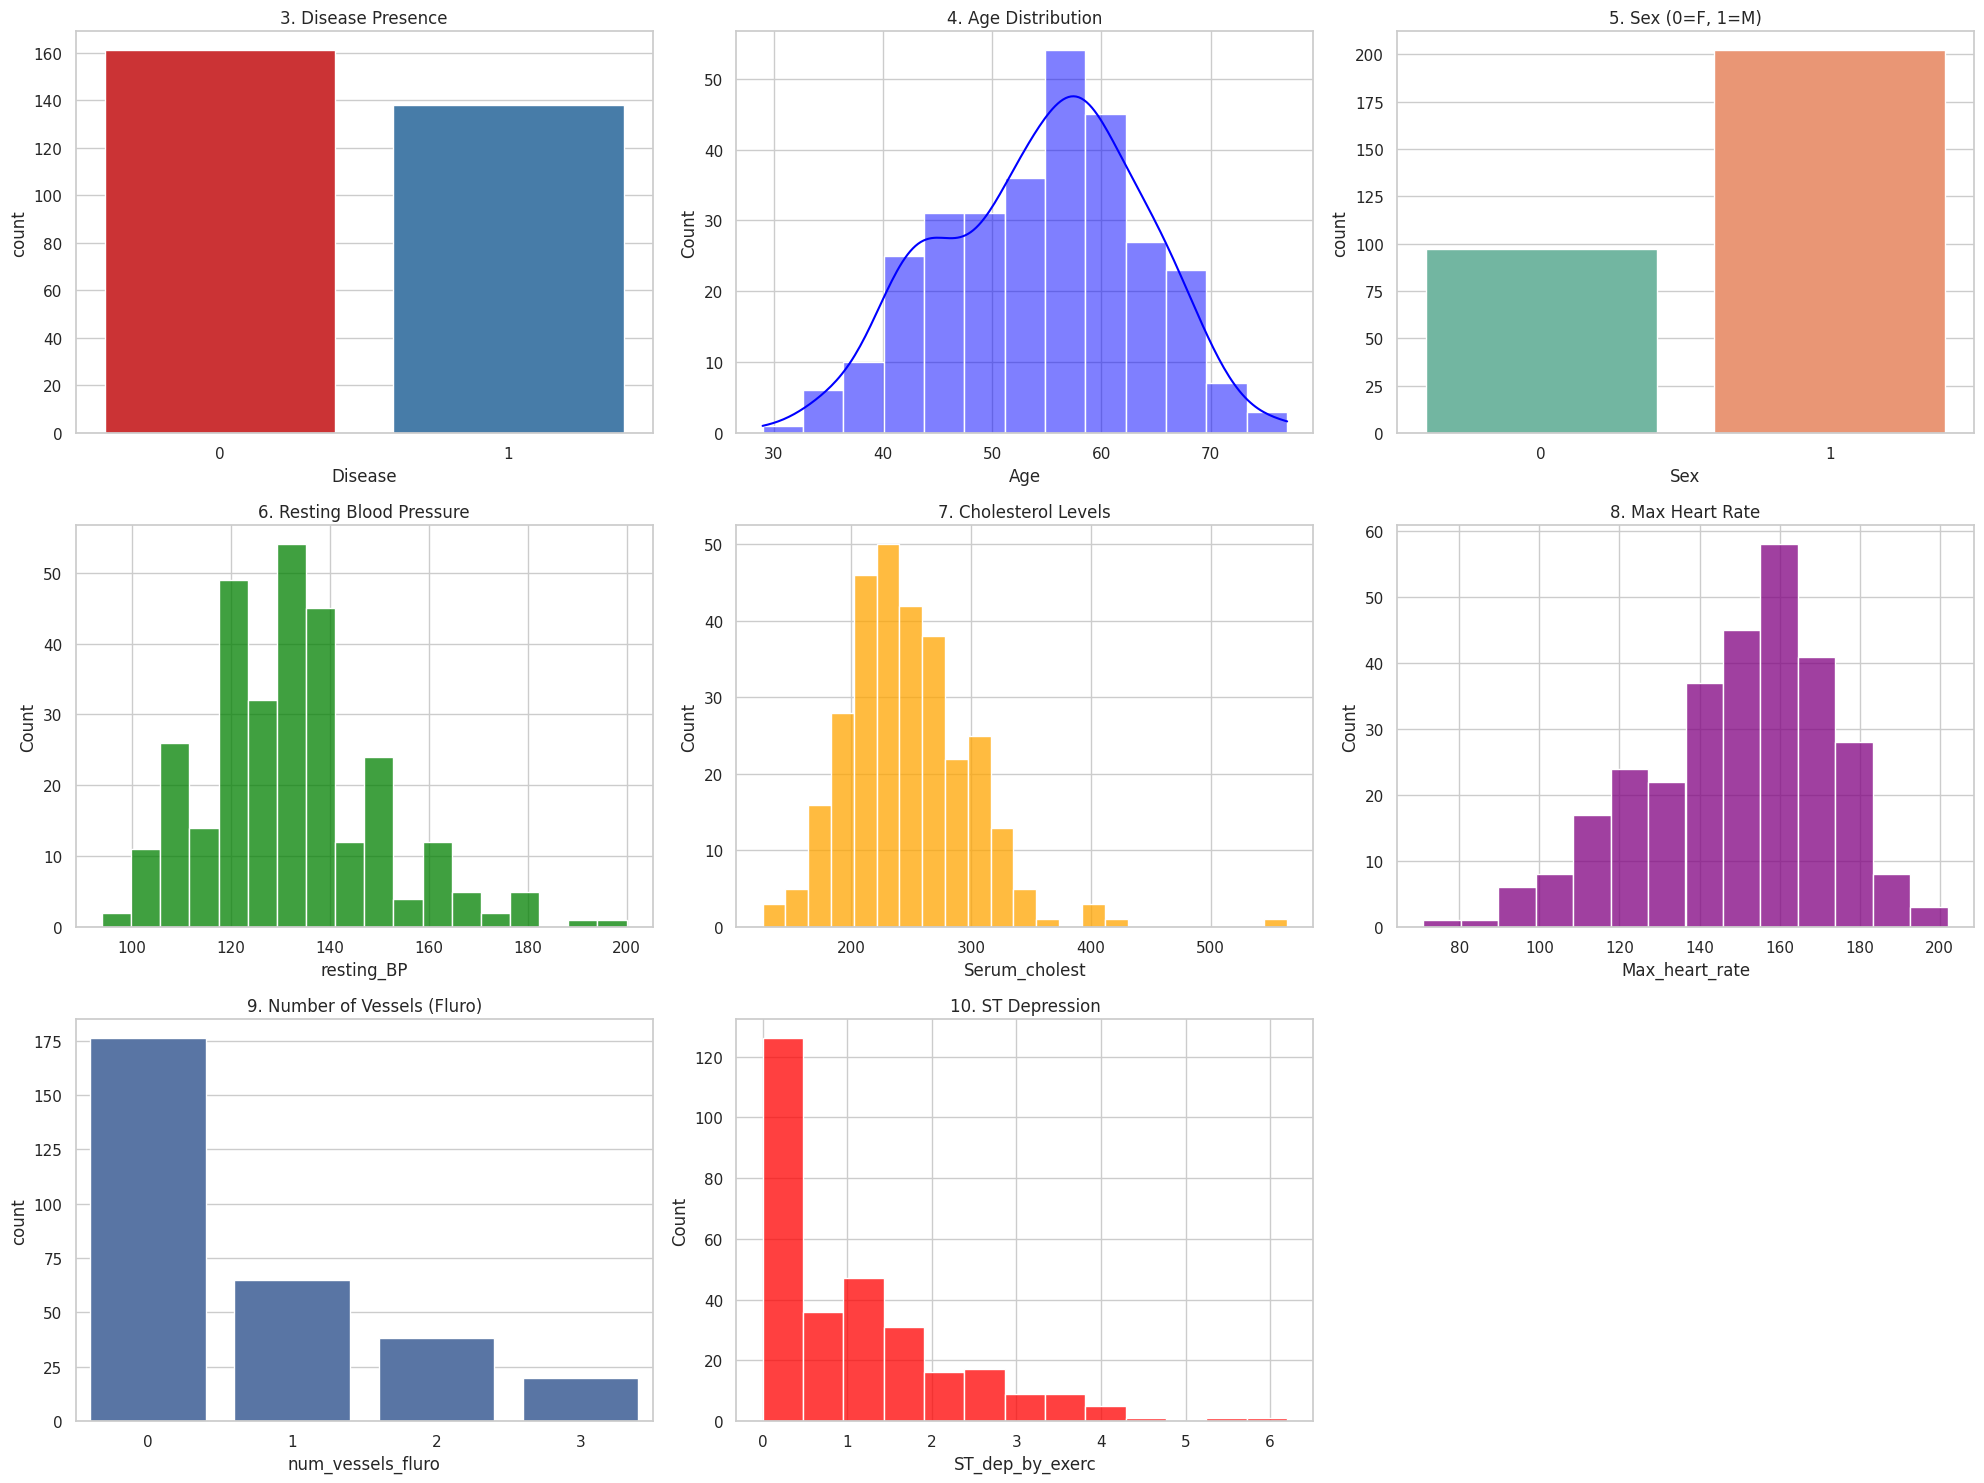

In [12]:
#Univariate Analysis
# Create a figure for multiple plots
plt.figure(figsize=(20, 15))

# Analysis 3: Disease Distribution
plt.subplot(3, 3, 1)
sns.countplot(x='Disease', data=df, palette='Set1').set_title('3. Disease Presence')

# Analysis 4: Age Distribution
plt.subplot(3, 3, 2)
sns.histplot(df['Age'], kde=True, color='blue').set_title('4. Age Distribution')

# Analysis 5: Sex Distribution
plt.subplot(3, 3, 3)
sns.countplot(x='Sex', data=df, palette='Set2').set_title('5. Sex (0=F, 1=M)')

# Analysis 6: Resting BP
plt.subplot(3, 3, 4)
sns.histplot(df['resting_BP'], color='green').set_title('6. Resting Blood Pressure')

# Analysis 7: Serum Cholesterol
plt.subplot(3, 3, 5)
sns.histplot(df['Serum_cholest'], color='orange').set_title('7. Cholesterol Levels')

# Analysis 8: Max Heart Rate
plt.subplot(3, 3, 6)
sns.histplot(df['Max_heart_rate'], color='purple').set_title('8. Max Heart Rate')

# Analysis 9: Number of Vessels
plt.subplot(3, 3, 7)
sns.countplot(x='num_vessels_fluro', data=df).set_title('9. Number of Vessels (Fluro)')

# Analysis 10: ST Depression
plt.subplot(3, 3, 8)
sns.histplot(df['ST_dep_by_exerc'], color='red').set_title('10. ST Depression')

plt.tight_layout()
plt.show()

# Distribution Analysis: Disease and Sex

*   Two count plots were generated to visualize the distribution of:

    **Disease Presence** (Disease column: 0 = Disease Present, 1 = No Disease)

    **Sex** (Sex column: 0 = Female, 1 = Male)

*   These plots provide a quick overview of:

    The **class balance** in the target variable (Disease).

    The **gender distribution** within the dataset.

*   **FutureWarning:**

    Seaborn raised a deprecation warning indicating that passing a palette without assigning hue will be removed in version v0.14.0.

    To ensure compatibility, the recommended adjustment is to assign the plotting variable (x) to hue and set legend=False.

**Key Insights**

*   The **Disease plot** helps confirm whether the dataset is balanced between patients with and without heart disease.

*   The **Sex plot** highlights the proportion of male vs. female patients, which is useful for demographic analysis and understanding potential biases in the dataset.

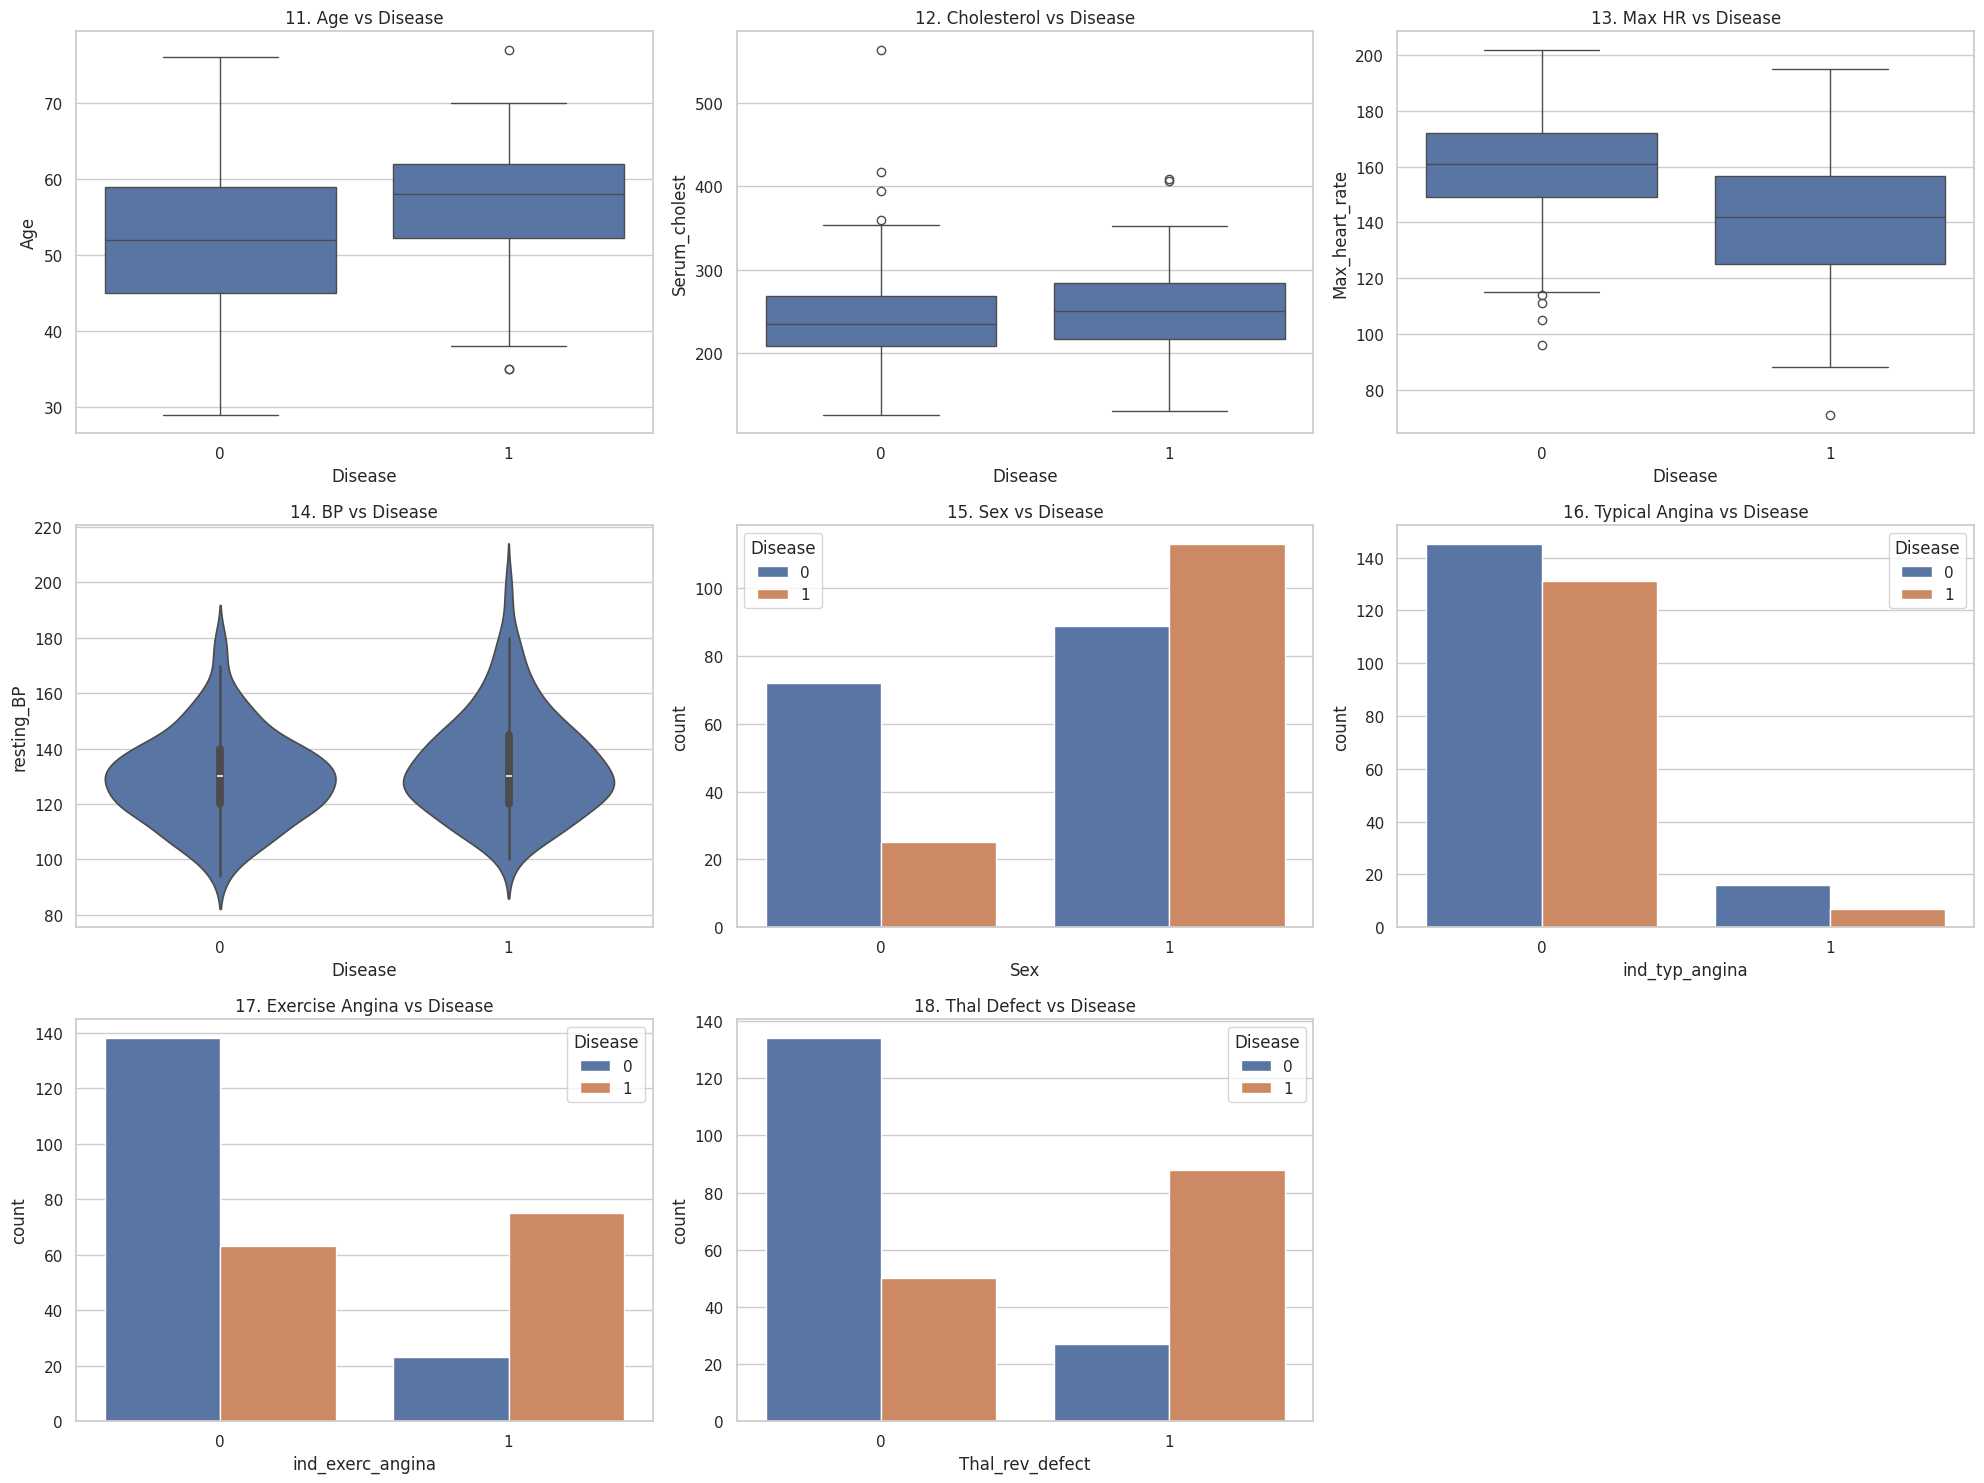

In [13]:
#Bivariate Analysis
plt.figure(figsize=(20, 15))

#Age vs Disease
plt.subplot(3, 3, 1)
sns.boxplot(x='Disease', y='Age', data=df).set_title('11. Age vs Disease')

#Cholesterol vs Disease
plt.subplot(3, 3, 2)
sns.boxplot(x='Disease', y='Serum_cholest', data=df).set_title('12. Cholesterol vs Disease')

#Max Heart Rate vs Disease
plt.subplot(3, 3, 3)
sns.boxplot(x='Disease', y='Max_heart_rate', data=df).set_title('13. Max HR vs Disease')

#BP vs Disease
plt.subplot(3, 3, 4)
sns.violinplot(x='Disease', y='resting_BP', data=df).set_title('14. BP vs Disease')

#Sex vs Disease
plt.subplot(3, 3, 5)
sns.countplot(x='Sex', hue='Disease', data=df).set_title('15. Sex vs Disease')

#Chest Pain (Angina) vs Disease
plt.subplot(3, 3, 6)
sns.countplot(x='ind_typ_angina', hue='Disease', data=df).set_title('16. Typical Angina vs Disease')

#Exercise Angina vs Disease
plt.subplot(3, 3, 7)
sns.countplot(x='ind_exerc_angina', hue='Disease', data=df).set_title('17. Exercise Angina vs Disease')

#Thalassemia (Rev Defect) vs Disease
plt.subplot(3, 3, 8)
sns.countplot(x='Thal_rev_defect', hue='Disease', data=df).set_title('18. Thal Defect vs Disease')

plt.tight_layout()
plt.show()

# Summary of Health Indicators vs Disease
1. **Age**: Individuals with disease tend to be older on average compared to those without disease.

2. **Cholesterol**: Higher cholesterol levels are more common among those with disease.

3. **Max Heart Rate**: People without disease generally show higher maximum heart rates than those with disease.

4. **Blood Pressure**: Resting blood pressure distributions overlap, but disease cases lean toward slightly higher values.

5. **Sex**: Disease prevalence differs by sex, with one group (likely males) showing higher counts.

6. **Typical Angina**: Strong association—those with typical angina are more likely to have disease.

7. **Exercise-Induced Angina**: Clear correlation—exercise angina is more frequent among disease cases.

8. **Thalassemia Defect**: Certain thal defects are significantly more represented in disease cases.

**Key Insight**

The plots highlight that age, cholesterol, heart rate, angina (both typical and exercise-induced), and thal defects are strong differentiators between individuals with and without disease. Blood pressure and sex also show patterns, though less pronounced.

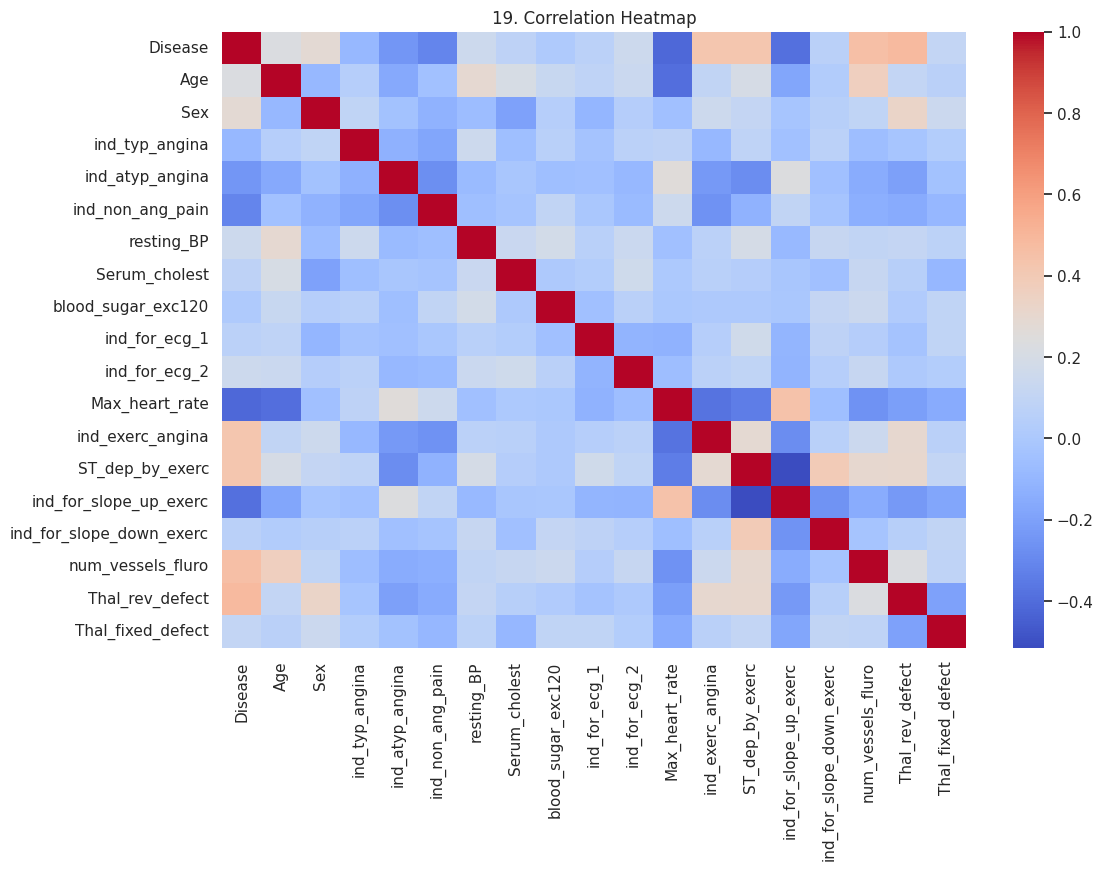

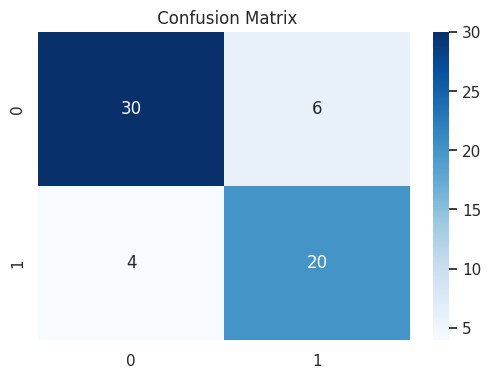

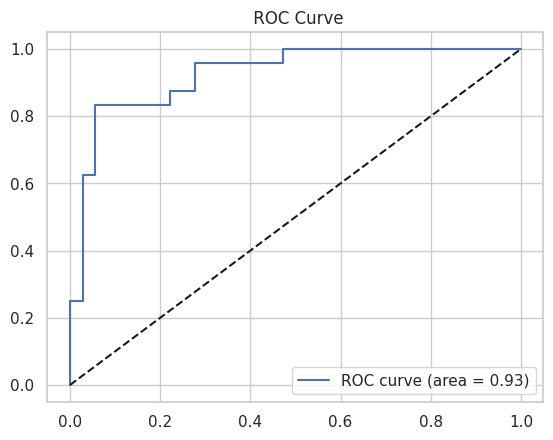

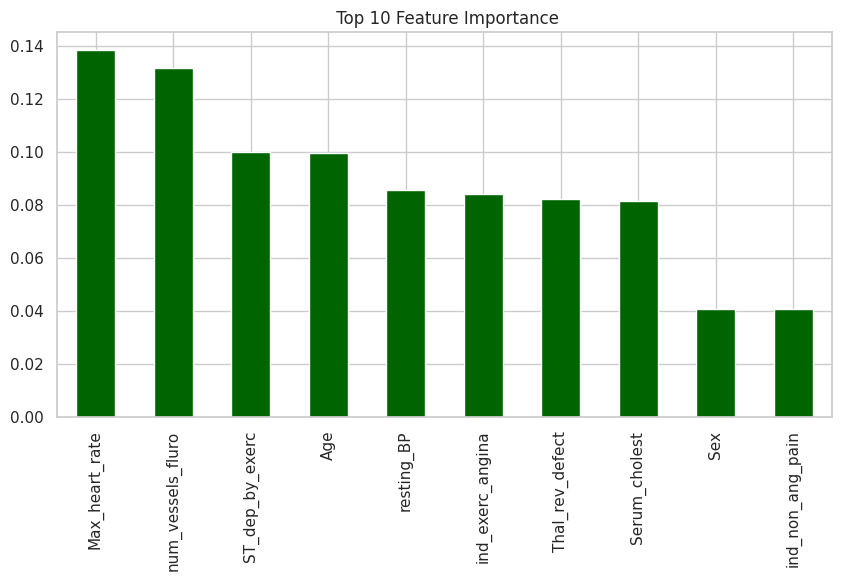


---Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        36
           1       0.77      0.83      0.80        24

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60

--- Overall Model Accuracy: 83.33% ---


In [15]:
#Multivariate & Modeling Analysis
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False).set_title('19. Correlation Heatmap')
plt.show()

# --- PREPARE MODEL ---
X = df.drop('Disease', axis=1)
y = df['Disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(' Confusion Matrix')
plt.show()

#ROC Curve (Receiver Operating Characteristic)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title(' ROC Curve')
plt.legend()
plt.show()

#Feature Importance (Top 10)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='darkgreen')
plt.title(' Top 10 Feature Importance')
plt.show()

#Classification Report (Precision, Recall, F1)
print("\n---Classification Report ---")
print(classification_report(y_test, y_pred))

#Prediction Success Rate (Accuracy Score)
accuracy = model.score(X_test, y_test)
print(f"--- Overall Model Accuracy: {accuracy:.2%} ---")

1.  **Health Indicators vs Disease**: Age, cholesterol, heart rate, angina, and thal defects are strong predictors of disease.

2.  **Correlation Heatmap:** The heatmap confirms that clinical symptoms (angina, thal defects, ST depression) are more predictive than demographic factors alone.

3.  **Confusion Matrix:** The model performs well, with balanced precision and recall, though some false positives and negatives remain.

4.  **ROC Curve:** The model is highly effective at distinguishing between classes.

**Overall Summary**

1.  *Data Analysis:* Age, cholesterol, heart rate, angina, and thal defects are critical indicators of disease.

2.  *Model Evaluation*: Confusion matrix shows good accuracy (83.3%), balanced precision/recall, and ROC curve confirms strong predictive power (AUC = 0.93).

3.  *Conclusion*: The classification model is reliable and effective for disease prediction, with potential for further refinement to reduce false positives/negatives.

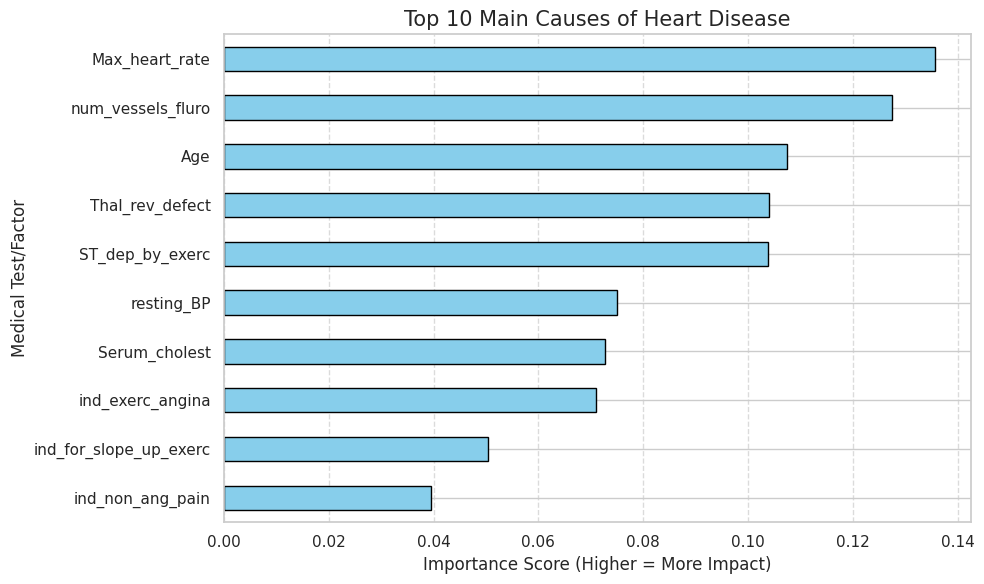

In [16]:
#Bar Chart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

#Load data and clean target
df = pd.read_csv('proc_heart_cleve_3_withheader.csv')
df['Disease'] = df['Disease'].map({-1: 0, 1: 1})

#Get Importance
X = df.drop('Disease', axis=1)
y = df['Disease']
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

#Create a clean Top 10 DataFrame
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = feat_importances.nlargest(10).sort_values(ascending=True)

#Plotting
plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='skyblue', edgecolor='black')

# Add simple titles
plt.title('Top 10 Main Causes of Heart Disease', fontsize=15)
plt.xlabel('Importance Score (Higher = More Impact)')
plt.ylabel('Medical Test/Factor')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Bar Chart

*   **Most impactful factor:**

    Maximum Heart Rate is the strongest predictor of heart disease.

*   **Other highly important factors:**

    Number of vessels observed via fluoroscopy

    Age

    Thalassemia reversible defect

    ST depression by exercise

*   **Moderately important contributors:**

    Resting Blood Pressure

    Serum Cholesterol

*   **Additional but lower-ranked factors:**

    Exercise-induced angina

    Slope of exercise response (upward)

    Non-anginal pain indicator

# Overall Conclusion
1.  The dataset is clean, balanced, and diverse, ideal for predictive modeling.

2.  Exercise-related features (heart rate, ST depression, angina) and imaging diagnostics (vessel count, thal defects) are the most critical predictors.

3.  The Random Forest model achieves 83% accuracy with an AUC of 0.93, making it a strong candidate for clinical decision support.

4.  Future improvements could focus on reducing false positives/negatives and testing other algorithms for comparison.